## load Library and Data


In [2]:
!pip install nltk wordcloud TextBlob vaderSentiment contractions

In [3]:
import numpy as numpy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



In [4]:
# lib for text analysis
import re
import nltk
import contractions
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from wordcloud import WordCloud
from collections import Counter
from textblob import TextBlob


In [5]:
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/andyzheng/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /Users/andyzheng/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/andyzheng/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/andyzheng/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [6]:

#import data
df = pd.read_csv('data/Hotel_Reviews.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10000 non-null  str    
 1   dateAdded             10000 non-null  str    
 2   dateUpdated           10000 non-null  str    
 3   address               10000 non-null  str    
 4   categories            10000 non-null  str    
 5   primaryCategories     10000 non-null  str    
 6   city                  10000 non-null  str    
 7   country               10000 non-null  str    
 8   keys                  10000 non-null  str    
 9   latitude              10000 non-null  float64
 10  longitude             10000 non-null  float64
 11  name                  10000 non-null  str    
 12  postalCode            10000 non-null  str    
 13  province              10000 non-null  str    
 14  reviews.date          10000 non-null  str    
 15  reviews.dateSeen      10000 non

In [7]:
df.head()
#will be reviewing review.text

,id,dateAdded,dateUpdated,address,categories,primaryCategories,city,country,keys,latitude,...,reviews.dateSeen,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sourceURLs,websites
0,AVwdik7FByjofQCxqHmQ,2016-11-02T14:11:46Z,2018-01-30T06:02:28Z,740 E Pike Ave,"Motels,Lodging,Hotels,Hotel",Accommodation & Food Services,Columbus,US,us/mt/columbus/740epikeave/-944721353,45.636420,...,"2016-05-05T00:00:00Z,2016-05-20T00:00:00Z",3.0,https://www.tripadvisor.com/Hotel_Review-g4512...,"After several hours on the road, decided to sh...",Return trip from Portland.,Aberdeen,SD,Earl A,https://www.yellowpages.com/columbus-mt/mip/gi...,http://www.bigskymotel.net
1,AVwdjJDaIN2L1WUfw53Z,2016-05-16T21:04:43Z,2018-01-29T07:35:24Z,309 SW Broadway,"Hotel,Hotels and motels,Hotels,Budget Hotels,B...",Accommodation & Food Services,Portland,US,us/or/portland/309swbroadway/1904963821,45.521848,...,2016-07-27T00:00:00Z,5.0,https://www.tripadvisor.com/Hotel_Review-g5202...,This was a very beautiful hotel. The rooms wer...,Gorgeous!,Aberdeen,WA,Theresa F,https://foursquare.com/v/the-benson-hotel/4abe...,"http://www.bensonhotel.com,http://www.coasthot..."
2,AWE7MLXnIxWefVJwyHZO,2018-01-28T05:10:34Z,2018-08-27T16:54:20Z,3820 Burgundy St,"Hotels,Bed and Breakfast and Inns,Hotel",Accommodation & Food Services,New Orleans,US,us/la/neworleans/3820burgundyst/-1099367129,29.963480,...,2018-08-26T00:00:00Z,5.0,https://www.tripadvisor.com/Hotel_Review-g6086...,"First time in New Orleans, planned to stay her...",Outstanding service,Aberdeen,UnitedKingdom,Elin208,https://www.tripadvisor.com/Hotel_Review-g6086...,http://www.maisonmacarty.com
3,AVwdUhstkufWRAb54qil,2015-10-28T16:32:51Z,2018-03-08T15:59:56Z,100 N West St,"Hotels,Lodging,Motels,Hotel",Accommodation & Food Services,Burnet,US,us/tx/burnet/100nwestst/1233394544,30.758350,...,"2016-05-14T00:00:00Z,2016-05-23T00:00:00Z",1.0,https://www.tripadvisor.com/Hotel_Review-g5555...,This is another typical motel run down by the ...,Another Motel ruined by India's ownership,Abilene,TX,DSSjammer,https://www.yellowpages.com/burnet-tx/mip/arro...,"http://www.arrowheadmoteltexas.com,http://arro..."
4,AVwedQ9okufWRAb5DFsQ,2015-10-23T02:40:17Z,2018-03-10T00:13:32Z,500 Cresson Blvd,"Hotel,Hotels and motels",Accommodation & Food Services,Phoenixville,US,us/pa/phoenixville/500cressonblvd/610480118,40.130295,...,2016-04-05T00:00:00Z,5.0,https://www.tripadvisor.com/Hotel_Review-g5343...,"Nice place to stay, neat and staff are very ho...",Home away from home,Abuja,NaN,Kingsley A,https://foursquare.com/v/hilton-garden-inn-val...,http://hiltongardeninn3.hilton.com/en/hotels/p...


## EDA, check for missing data

In [8]:
df.isnull().sum()

id                         0
dateAdded                  0
dateUpdated                0
address                    0
categories                 0
primaryCategories          0
city                       0
country                    0
keys                       0
latitude                   0
longitude                  0
name                       0
postalCode                 0
province                   0
reviews.date               0
reviews.dateSeen           0
reviews.rating             0
reviews.sourceURLs         0
reviews.text               1
reviews.title              1
reviews.userCity        5836
reviews.userProvince    1507
reviews.username           0
sourceURLs                 0
websites                   0
dtype: int64

In [9]:
# Fill missing text with Empty space
df['reviews.text'] = df['reviews.text'].fillna('').astype(str)
df['reviews.text'].info()

<class 'pandas.Series'>
RangeIndex: 10000 entries, 0 to 9999
Series name: reviews.text
Non-Null Count  Dtype
--------------  -----
10000 non-null  str  
dtypes: str(1)
memory usage: 78.3 KB


In [10]:
#change datatypes
df['categories'] = df['categories'].astype('category')

df['primaryCategories'] = df['primaryCategories'].astype('category')

df['city'] = df['city'].astype('category')

df['dateAdded'] = pd.to_datetime(df['dateAdded'])
df['dateUpdated'] = pd.to_datetime(df['dateUpdated'])

#df['reviews.date'] = pd.to_datetime(df['reviews.date'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   id                    10000 non-null  str                
 1   dateAdded             10000 non-null  datetime64[us, UTC]
 2   dateUpdated           10000 non-null  datetime64[us, UTC]
 3   address               10000 non-null  str                
 4   categories            10000 non-null  category           
 5   primaryCategories     10000 non-null  category           
 6   city                  10000 non-null  category           
 7   country               10000 non-null  str                
 8   keys                  10000 non-null  str                
 9   latitude              10000 non-null  float64            
 10  longitude             10000 non-null  float64            
 11  name                  10000 non-null  str                
 12  postalCode      

In [11]:
#skip visualization as its not that important for text


## preprocessing

In [12]:
# initiate Lemmaatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
#exclude negation words
negation = {'no', 'not', 'nor', 'never'}
stop_words = stop_words - negation
#add new stopwords you like
stop_words. update(['would', 'us', 'one'])



In [13]:
df['cleaned_reviews'] = df['reviews.text'].str.lower() #make it lowercase 
#expand contractions (e.g., don't  --> do not)
df['cleaned_reviews'] = df['cleaned_reviews'].apply(contractions.fix)
df['cleaned_reviews'] = df['cleaned_reviews'].str.replace(r'[^a-z\s]', '', regex = True) # remove special characters
df['cleaned_reviews'] = df['cleaned_reviews'].str.split().str.join(" ") # remove empty space 

In [14]:
#Tokenization
df['tokenized_reviews'] = df['cleaned_reviews'].apply(word_tokenize)

In [15]:
#remove stopwords
df['tokenized_reviews'] = df['tokenized_reviews'].apply(lambda words: [word for word in words if word not in stop_words]) 

In [16]:
#lemmatization
df['tokenized_reviews'] = df['tokenized_reviews'].apply(lambda words : [lemmatizer.lemmatize(word) for word in words])

## Descriptive Analysis : WordCloud

In [17]:
#combine all words from text (bag of words)
all_words = [word for words in df['tokenized_reviews'] for word in words]

In [18]:
# Count word frequencies 
word_freq = Counter(all_words) 

In [19]:
# Convert to DataFrame for visualization 
word_freq_df = pd.DataFrame(word_freq.items(), columns=['Word', 'Frequency']).sort_values(by='Frequency', ascending=False) 


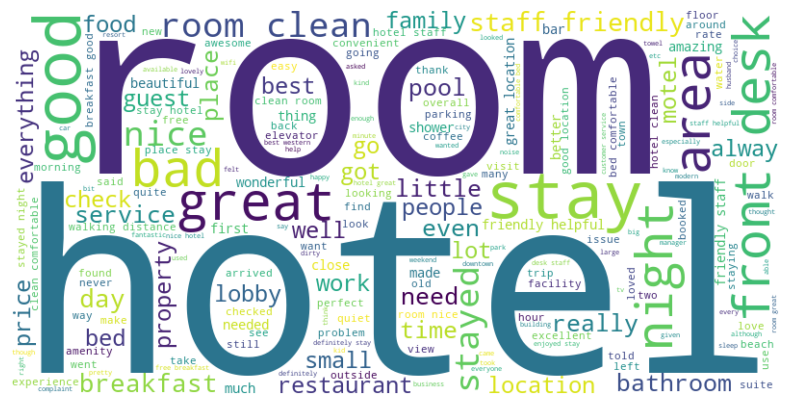

In [20]:
# Generate word cloud 
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(all_words)) 

# Display word cloud 
plt.figure(figsize=(10, 5)) 
plt.imshow(wordcloud, interpolation="bilinear") 
plt.axis("off") 
plt.show()


## Sentiment analysis


In [21]:
# Most VADER and TextBlob have built in tokenization and lemmatization 
# Because of this, we only need to use the cleaned_reviews text here

# Vader Analysis
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyser = SentimentIntensityAnalyzer()

In [22]:
df['vader_sentiment'] = df['cleaned_reviews'].apply(
    lambda text:analyser.polarity_scores(text)['compound']
)

In [23]:
# TextBlob Analysis
df['blob_sentiment'] = df['cleaned_reviews'].apply(
    lambda text:TextBlob(text).sentiment.polarity
)

In [24]:
sentiment_output = df[['reviews.text', 'vader_sentiment', 'blob_sentiment']].copy()
sentiment_output.to_csv('seniment_output.csv')
#manually review and decide to use VADER sentiment scores

## Interperet the sentiment scores


In [25]:
sentiment_output = df.groupby(['name','city'])[['vader_sentiment']].mean().reset_index()
sentiment_output.head(10)


,name,city,vader_sentiment
0,1906 Lodge At Coronado Beach,Coronado,0.965700
1,250 Main Hotel,Rockland,0.894950
2,AC Hotel Chicago Downtown,Chicago,0.362627
3,AC Hotel Miami Beach,Miami Beach,0.981400
4,AC Hotel by Marriott Boston Downtown,Boston,0.790600
5,ARIA Resort Casino,Las Vegas,0.744482
6,Acadia Suites,Bar Harbor,0.882750
7,Ace Hotel Chicago,Chicago,0.363925
8,Ace Hotel New Orleans,New Orleans,0.883767
9,Admiral Hotel,Arlington,-0.296000


In [26]:
sentiment_output.tail(10)

,name,city,vader_sentiment
1843,Wyndham Garden Lafayette,Lafayette,0.485117
1844,Wyndham Garden Pittsburgh Airport,Pittsburgh,0.030650
1845,Wyndham Garden San Jose Silicon Valley,San Jose,0.440022
1846,Wyndham Garden-amarillo,Amarillo,-0.609450
1847,Wyndham Houston - Medical Center Hotel and Suites,Houston,0.407350
1848,XV Beacon,Boston,0.958300
1849,Yakutat Lodge,Yakutat,0.956500
1850,dana hotel and spa,Chicago,0.404480
1851,hampton inn Springfield southeast,Springfield,0.778450
1852,hotel le bleu,Brooklyn,0.878367


In [27]:
df[['reviews.text', 'vader_sentiment', 'blob_sentiment']]

,reviews.text,vader_sentiment,blob_sentiment
0,"After several hours on the road, decided to sh...",0.7184,0.134921
1,This was a very beautiful hotel. The rooms wer...,0.9041,0.398333
2,"First time in New Orleans, planned to stay her...",0.9942,0.247211
3,This is another typical motel run down by the ...,0.2732,0.023016
4,"Nice place to stay, neat and staff are very ho...",0.9272,0.311111
...,...,...,...
9995,Good: Excellent location and good price for mo...,0.9371,0.463095
9996,Good: The staff was very friendly and helpful ...,0.9711,0.590833
9997,Bad: No microwave. Good: The shower was amazing,-0.5116,0.200000
9998,Bad: Needs Security by the pool had a very bad...,-0.4576,-0.122000


In [28]:
all_words = [word for words in df['tokenized_reviews']for word in words]

In [29]:
#convert to a df for analysis 
word_freq = Counter(all_words)

In [30]:
#convert to a df for analysis 
word_freq_df = pd.DataFrame(word_freq.items(),
                            columns=['Word', 'Frequency']).sort_values(by='Frequency', ascending = False)

In [31]:
word_freq_df.head(20)

,Word,Frequency
28,room,8796
27,hotel,7172
147,not,6251
152,staff,4008
22,stay,3786
72,good,3481
57,great,3475
30,clean,3315
65,breakfast,2932
150,nice,2781


In [32]:
#classify the scores
def classify_sentiment(score):
    if score > 0.2:
        return "positive"
    elif score < -0.2:
        return "negative"
    else:
        return "neutral"
    
sentiment_output['label'] = sentiment_output['vader_sentiment'].apply(classify_sentiment)

In [ ]:
sentiment_output.head()

,name,city,vader_sentiment,label
0,1906 Lodge At Coronado Beach,Coronado,0.965700,positive
1,250 Main Hotel,Rockland,0.894950,positive
2,AC Hotel Chicago Downtown,Chicago,0.362627,positive
3,AC Hotel Miami Beach,Miami Beach,0.981400,positive
4,AC Hotel by Marriott Boston Downtown,Boston,0.790600,positive


In [34]:
#count lavels 
vader_counters= sentiment_output['label'].value_counts()

<Axes: xlabel='label'>

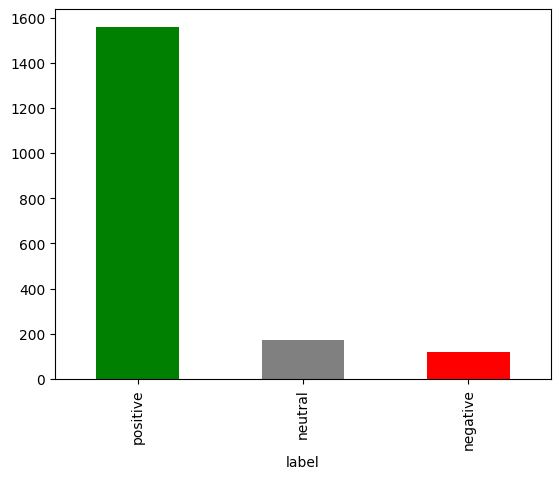

In [35]:
#visualize labels
#define Colors 
colors_vader = {'positive':'green',
                'neutral':'grey',
                'negative':'red'}
vader_counters.plot(kind = 'bar', color = [colors_vader[label]for  label in vader_counters.index])

In [36]:
#export data out for tableau
df.to_csv('tableau_hotels.csv')

In [37]:
df['reviews.date'] = pd.to_datetime (df['reviews.date'], format='%Y-%m-%dT%H:%M:%S%z', errors= 'coerce' )

/var/folders/z6/ljcqgf2s11j6ypxy3rs3mq240000gn/T/ipykernel_40117/3616361391.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df.groupby(df['reviews.date'].dt.to_period('M'))['vader_sentiment'].mean().plot()


<Axes: xlabel='reviews.date'>

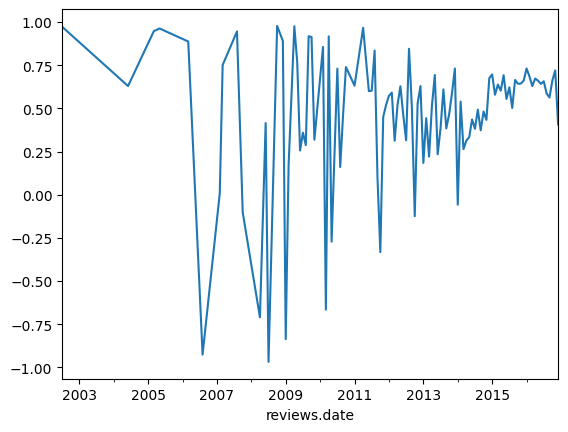

In [38]:
df.groupby(df['reviews.date'].dt.to_period('M'))['vader_sentiment'].mean().plot()

In [39]:
sentiment_output.tail(10)

,name,city,vader_sentiment,label
1843,Wyndham Garden Lafayette,Lafayette,0.485117,positive
1844,Wyndham Garden Pittsburgh Airport,Pittsburgh,0.030650,neutral
1845,Wyndham Garden San Jose Silicon Valley,San Jose,0.440022,positive
1846,Wyndham Garden-amarillo,Amarillo,-0.609450,negative
1847,Wyndham Houston - Medical Center Hotel and Suites,Houston,0.407350,positive
1848,XV Beacon,Boston,0.958300,positive
1849,Yakutat Lodge,Yakutat,0.956500,positive
1850,dana hotel and spa,Chicago,0.404480,positive
1851,hampton inn Springfield southeast,Springfield,0.778450,positive
1852,hotel le bleu,Brooklyn,0.878367,positive
